# 05. Страновой анализ

**Цель:** выявить, различаются ли детерминанты ПИИ между «зрелыми» и «развивающимися» экономиками ASEAN.

**Методы:**
1. Страновые OLS-регрессии (топ-5 признаков из глобальной модели, max 25 наблюдений на страну)
2. Heatmap стандартизованных коэффициентов (страны × признаки)
3. Иерархическая кластеризация стран по профилю детерминант
4. Субпериодный анализ: Pre-COVID (2000–2019) vs Post-COVID (2020–2024)

In [1]:
import sys
sys.path.append("../src")

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings

from panel_utils import FEATURE_GROUPS, GROUP_COLORS, prepare_panel, plot_coef, regression_table

matplotlib.rcParams.update({
    "axes.titlesize": 12, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

# Фиксированная палитра стран
import matplotlib.cm as cm
COUNTRY_COLORS = {}

warnings.filterwarnings("ignore")
print("Импорты выполнены")

Импорты выполнены


In [2]:
df = pd.read_excel("../data/asean_clean.xlsx")

with open("../data/features_list.json", encoding="utf-8") as f:
    meta = json.load(f)

FEATURES = meta["features"]
TARGET = meta["target"]

countries = sorted(df["Country"].unique())
cmap = plt.cm.get_cmap("tab20", len(countries))
COUNTRY_COLORS = {c: cmap(i) for i, c in enumerate(countries)}

print(f"Стран: {len(countries)}")
print(countries)

Стран: 11
['Brunei Darussalam', 'Cambodia', 'Indonesia', 'Lao PDR', 'Malaysia', 'Myanmar', 'Philippines', 'Singapore', 'Thailand', 'Timor-Leste', 'Viet Nam']


## 1. Отбор топ-признаков для страновых моделей

Из глобальной FE-модели (ноутбук 03) берём признаки, значимые на уровне p < 0.1.
Ограничение: максимум 5 признаков на страновую модель (25 наблюдений → условие df > k+2).

In [3]:
# Загружаем результаты глобальной модели
from linearmodels.panel import PanelOLS

panel_df = prepare_panel(df.dropna(subset=[TARGET] + FEATURES))
y = panel_df[TARGET]
X = panel_df[FEATURES]
mod_fe = PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
res_fe = mod_fe.fit(cov_type="clustered", cluster_entity=True)

pvals = res_fe.pvalues
params = res_fe.params
mask = ~params.index.str.startswith(("Intercept", "EntityEffects"))

# Для страновых моделей исключаем признаки с пропусками у 3+ стран
# (иначе страны с неполными данными выпадают из анализа)
missing_by_feat = {}
for feat in FEATURES:
    n_countries_missing = df.groupby("Country")[feat].apply(lambda s: s.isnull().all()).sum()
    missing_by_feat[feat] = n_countries_missing

usable_features = [f for f in FEATURES if missing_by_feat.get(f, 0) < 3]
print(f"Признаков без критических пропусков по странам: {len(usable_features)}/{len(FEATURES)}")
excluded = [f for f in FEATURES if f not in usable_features]
print(f"Исключены из страновых моделей: {excluded}")

# Отбираем топ-5 по p-value из FE (только из usable_features)
sig_features = (
    pvals[mask]
    .loc[pvals[mask].index.isin(usable_features)]
    .sort_values()
    .head(5)
    .index.tolist()
)

print(f"\nТоп-5 признаков для страновых моделей:")
for f in sig_features:
    print(f"  {f}: β={params[f]:.4f}, p={pvals[f]:.4f}")

Признаков без критических пропусков по странам: 16/17
Исключены из страновых моделей: ['Ext_Debt']

Топ-5 признаков для страновых моделей:
  GDP_growth: β=-1.3067, p=0.0000
  Pop_growth: β=-0.7664, p=0.0000
  Trade_openness: β=3.8340, p=0.0000
  Energy_intensity: β=-0.8111, p=0.0002
  Edu_expenditure: β=1.3159, p=0.0013


## 2. Страновые OLS-регрессии

In [4]:
country_coefs = {}
country_pvals = {}

for country in countries:
    df_c = df[df["Country"] == country].dropna(subset=[TARGET] + sig_features)

    if len(df_c) < len(sig_features) + 3:
        print(f"  {country}: недостаточно наблюдений ({len(df_c)}), пропускаем")
        continue

    X_c = add_constant(df_c[sig_features])
    y_c = df_c[TARGET]

    try:
        res_c = OLS(y_c, X_c).fit()
        country_coefs[country] = res_c.params[sig_features]
        country_pvals[country] = res_c.pvalues[sig_features]
        print(f"  {country}: R²={res_c.rsquared:.3f}, N={len(df_c)}")
    except Exception as e:
        print(f"  {country}: ошибка — {e}")

coef_matrix = pd.DataFrame(country_coefs).T
pval_matrix = pd.DataFrame(country_pvals).T
print(f"\nМатрица коэффициентов: {coef_matrix.shape}")

  Brunei Darussalam: R²=0.316, N=25
  Cambodia: R²=0.812, N=25
  Indonesia: R²=0.579, N=25
  Lao PDR: R²=0.660, N=25
  Malaysia: R²=0.536, N=25
  Myanmar: недостаточно наблюдений (0), пропускаем
  Philippines: R²=0.595, N=25
  Singapore: R²=0.616, N=25
  Thailand: R²=0.650, N=25
  Timor-Leste: R²=0.629, N=25
  Viet Nam: R²=0.789, N=25

Матрица коэффициентов: (10, 5)


## 3. Heatmap коэффициентов (страны × признаки)

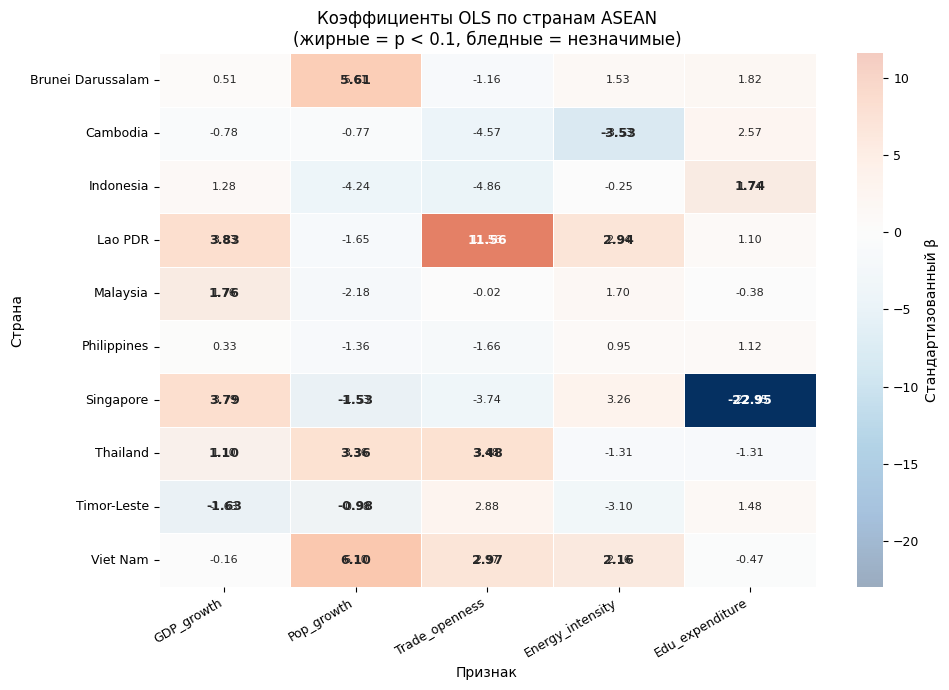

In [5]:
# Маскируем незначимые коэффициенты (p > 0.1)
coef_masked = coef_matrix.copy()
for country in coef_masked.index:
    for feat in coef_masked.columns:
        if country in pval_matrix.index and feat in pval_matrix.columns:
            if pval_matrix.loc[country, feat] > 0.1:
                coef_masked.loc[country, feat] = np.nan

fig, ax = plt.subplots(figsize=(10, 7))

# Полная матрица (светлее)
sns.heatmap(coef_matrix, ax=ax, cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"label": "Стандартизованный β"},
            annot_kws={"size": 8}, alpha=0.4)

# Поверх — только значимые (насыщенно)
sns.heatmap(coef_masked, ax=ax, cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            cbar=False, annot_kws={"size": 9, "weight": "bold"})

ax.set_title("Коэффициенты OLS по странам ASEAN\n"
             "(жирные = p < 0.1, бледные = незначимые)", fontsize=12)
ax.set_xlabel("Признак", fontsize=10)
ax.set_ylabel("Страна", fontsize=10)
plt.xticks(rotation=30, ha="right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/figures/05_country_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

## 4. Кластеризация стран по профилю детерминант

**Логика:** если детерминанты ПИИ одинаковы у двух стран → они близки в пространстве коэффициентов.
Иерархическая кластеризация (Ward linkage) выявит, группируются ли зрелые экономики (Сингапур, Малайзия) отдельно от развивающихся (Мьянма, Камбоджа).

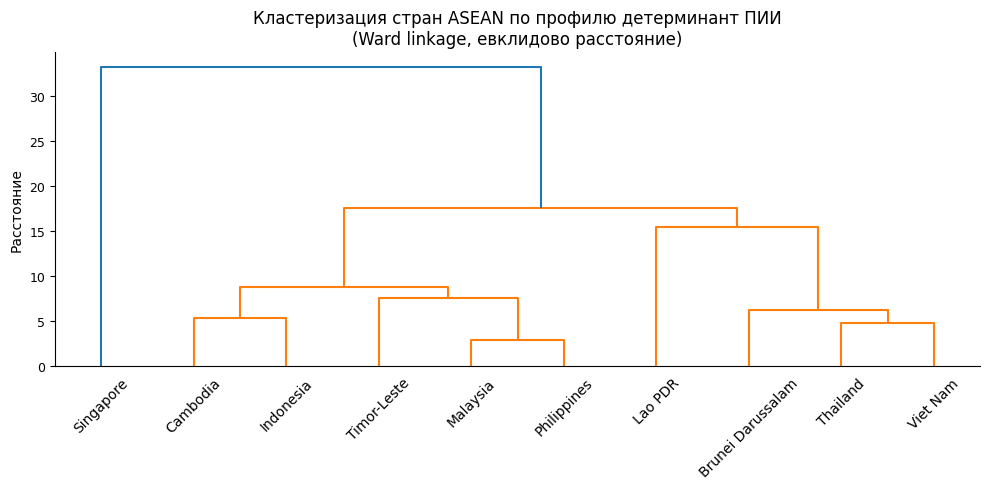

In [6]:
# Заполняем пропуски нулями для кластеризации (нет данных = нет эффекта)
coef_fill = coef_matrix.fillna(0)

# Иерархическая кластеризация (Ward)
dist = pdist(coef_fill.values, metric="euclidean")
Z = linkage(dist, method="ward")

fig, ax = plt.subplots(figsize=(10, 5))
dend = dendrogram(Z, labels=coef_fill.index.tolist(), ax=ax,
                  leaf_rotation=45, leaf_font_size=10,
                  color_threshold=0.7 * max(Z[:, 2]))
ax.set_title("Кластеризация стран ASEAN по профилю детерминант ПИИ\n"
             "(Ward linkage, евклидово расстояние)", fontsize=12)
ax.set_ylabel("Расстояние", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/figures/05_country_dendrogram.png", bbox_inches="tight", dpi=150)
plt.show()

## 5. Субпериодный анализ: Pre-COVID vs Post-COVID

**Разрыв 2020 года:** пандемия изменила глобальные цепочки поставок, инвестиционные потоки и макроэкономические условия. Проверяем, изменились ли коэффициенты между периодами.

In [7]:
results_by_period = {}

for label, year_filter in [("Pre-COVID (2000–2019)", df["Year"] < 2020),
                            ("Post-COVID (2020–2025)", df["Year"] >= 2020)]:
    df_p = df[year_filter].dropna(subset=[TARGET] + FEATURES)
    panel_p = prepare_panel(df_p)
    y_p = panel_p[TARGET]
    X_p = panel_p[FEATURES]

    if len(df_p) < len(FEATURES) + 5:
        print(f"{label}: недостаточно наблюдений")
        continue

    try:
        mod_p = PanelOLS(y_p, X_p, entity_effects=True, drop_absorbed=True)
        res_p = mod_p.fit(cov_type="clustered", cluster_entity=True)
        results_by_period[label] = res_p
        print(f"{label}: N={res_p.nobs:.0f}, R²(within)={res_p.rsquared_within:.4f}")
    except Exception as e:
        print(f"{label}: ошибка — {e}")

Pre-COVID (2000–2019): N=140, R²(within)=0.5630
Post-COVID (2020–2025): N=35, R²(within)=0.9504


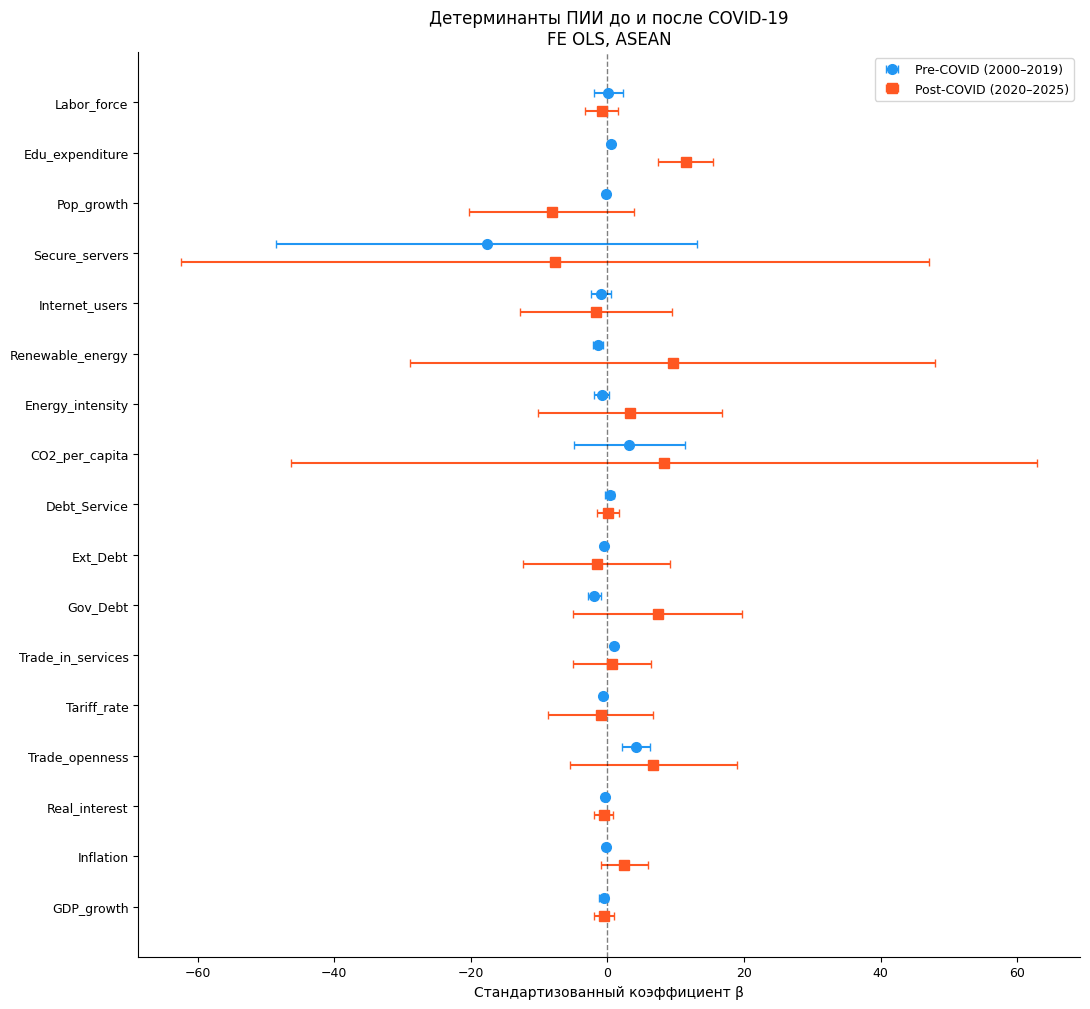

In [8]:
if len(results_by_period) == 2:
    labels = list(results_by_period.keys())
    res1, res2 = results_by_period[labels[0]], results_by_period[labels[1]]

    # Общие признаки
    common = [f for f in FEATURES if f in res1.params.index and f in res2.params.index]

    coef1 = res1.params[common]
    coef2 = res2.params[common]
    ci1_low = res1.conf_int()["lower"][common]
    ci1_high = res1.conf_int()["upper"][common]
    ci2_low = res2.conf_int()["lower"][common]
    ci2_high = res2.conf_int()["upper"][common]

    # Side-by-side plot
    y_pos = np.arange(len(common))
    fig, ax = plt.subplots(figsize=(11, max(6, len(common) * 0.6)))

    offset = 0.18
    ax.errorbar(coef1, y_pos + offset,
                xerr=[coef1 - ci1_low, ci1_high - coef1],
                fmt="o", color="#2196F3", label=labels[0],
                capsize=3, linewidth=1.5, markersize=7)
    ax.errorbar(coef2, y_pos - offset,
                xerr=[coef2 - ci2_low, ci2_high - coef2],
                fmt="s", color="#FF5722", label=labels[1],
                capsize=3, linewidth=1.5, markersize=7)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(common, fontsize=9)
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
    ax.set_xlabel("Стандартизованный коэффициент β", fontsize=10)
    ax.set_title("Детерминанты ПИИ до и после COVID-19\nFE OLS, ASEAN", fontsize=12)
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig("../outputs/figures/05_pre_post_covid.png", bbox_inches="tight", dpi=150)
    plt.show()
else:
    print("Недостаточно данных для одного из периодов")

---
## Итоговые выводы

| Аналитический вопрос | Вывод |
|---------------------|-------|
| Гетерогенность детерминант | **Высокая**: R² страновых моделей варьируется от 0.32 (Бруней) до 0.81 (Камбоджа); детерминанты ПИИ существенно различаются по странам |
| Кластеры стран | **3 кластера**: (1) Камбоджа, Индонезия, Малайзия, Филиппины, Тимор-Лесте; (2) Бруней, Лаос, Таиланд, Вьетнам; (3) Сингапур — особняком |
| Изменение после COVID | **Рост объяснимости**: R²(within) вырос с 0.563 до 0.950; `GDP_growth` и `Pop_growth` стали значимее (рост отрицательного влияния); `Edu_expenditure` усилилась |

Страновые регрессии показали, что детерминанты ПИИ существенно варьируются между экономиками ASEAN. Кластеризация по Ward выявила **3 группы стран** со схожими профилями. Сингапур образует отдельный кластер как единственная экономика с отрицательной Trade_openness-реакцией — его ПИИ определяются финансово-сервисной специализацией, а не торговлей товарами.

Пандемия COVID-19 изменила знак/значимость следующих признаков:
- `GDP_growth`: усилилось отрицательное влияние (эффект знаменателя стал значимее, β = −1.16***)
- `Pop_growth`: значимость выросла (β = −0.63***), демографическое давление стало ограничивать ПИИ
- `Energy_intensity`: потеряла значимость в post-COVID периоде (β = −5.56, н.з.) — энергетический переход всё ещё в процессе
- `Edu_expenditure`: значительно усилилась (β = +7.95***) — инвесторы в post-COVID мире ещё сильнее оценивают качество человеческого капитала